In [8]:
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score

import pickle 

In [9]:
df=pd.read_csv('/kaggle/input/datasets/aa10sh/vehicle-insurrance-prediction/train.csv')

In [10]:
df.sample(5)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
245887,245888,Male,24,1,30.0,1,< 1 Year,No,50503.0,152.0,20,0
9792,9793,Male,48,1,28.0,0,1-2 Year,Yes,71371.0,163.0,125,0
107413,107414,Male,23,1,23.0,0,1-2 Year,Yes,2630.0,156.0,68,0
28323,28324,Male,50,1,38.0,0,1-2 Year,Yes,33062.0,155.0,248,0
245114,245115,Female,45,1,41.0,0,1-2 Year,Yes,37507.0,124.0,204,1


In [11]:
df.shape

(381109, 12)

In [12]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [14]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [15]:
df.describe(include = 'object')

,Gender,Vehicle_Age,Vehicle_Damage
count,381109,381109,381109
unique,2,3,2
top,Male,1-2 Year,Yes
freq,206089,200316,192413


In [16]:
df.describe(include = 'object')

,Gender,Vehicle_Age,Vehicle_Damage
count,381109,381109,381109
unique,2,3,2
top,Male,1-2 Year,Yes
freq,206089,200316,192413


<Axes: xlabel='Gender'>

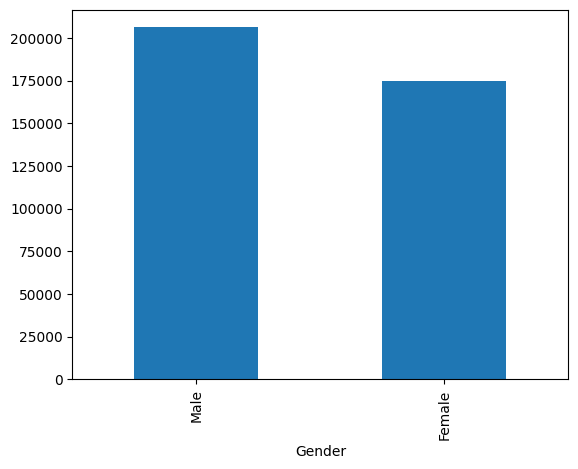

In [17]:
df.Gender.value_counts().plot(kind='bar') 

Driving_License
1    380297
0       812
Name: count, dtype: int64

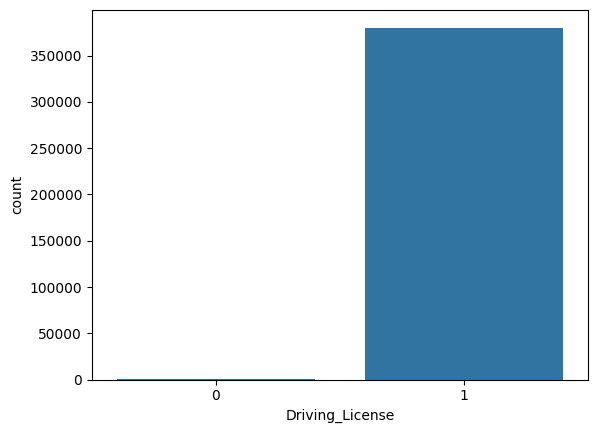

In [18]:
sns.countplot(x='Driving_License',data=df)
df['Driving_License'].value_counts()

<Axes: xlabel='Previously_Insured', ylabel='count'>

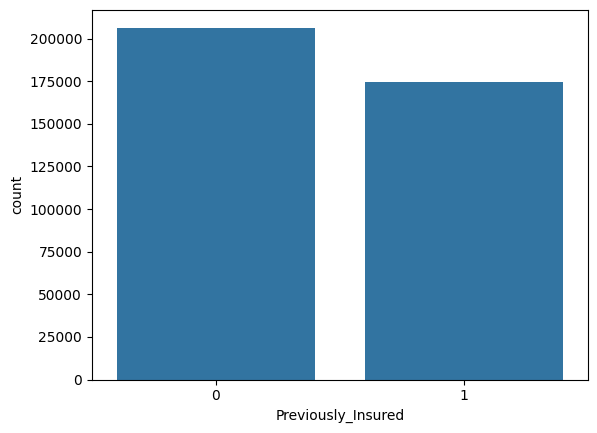

In [19]:
sns.countplot(x='Previously_Insured', data=df)

<Axes: xlabel='Vehicle_Age', ylabel='count'>

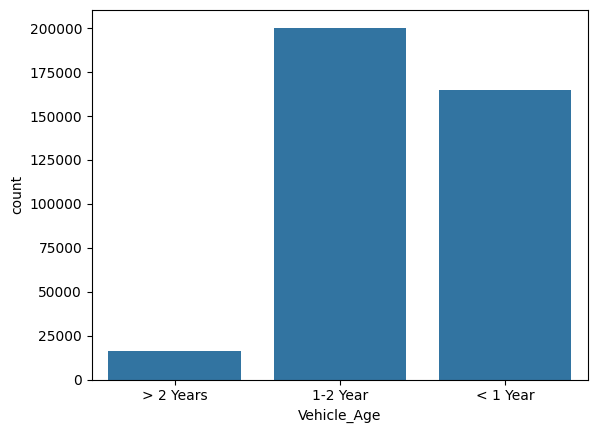

In [20]:
sns.countplot(x=df.Vehicle_Age,data =df)

<Axes: xlabel='Age', ylabel='Density'>

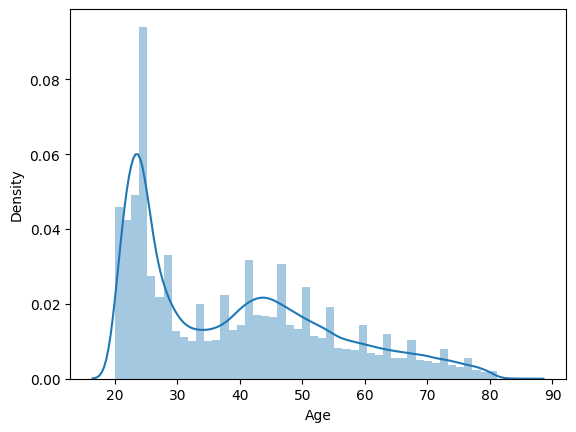

In [21]:
# Distplot
sns.distplot(df['Age'])

In [22]:
df['Age'].skew()

np.float64(0.6725389977260843)

# Data Preprocessing

**Three categorical columns are there
1. Gender
2. Vehicle age
3. vehicle damage**

In [23]:
df.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [24]:
df.Gender.replace({'Male':1,'Female':2}, inplace=True)

In [25]:
df.Gender.unique()

array([1, 2])

In [26]:
df.Vehicle_Damage.unique()

array(['Yes', 'No'], dtype=object)

In [27]:
df.Vehicle_Damage.replace({'Yes':1,'No':0}, inplace=True)

In [28]:
df.Vehicle_Age.unique() 

array(['> 2 Years', '1-2 Year', '< 1 Year'], dtype=object)

In [29]:
df.Vehicle_Age.replace({'< 1 Year':1,'1-2 Year':2,'> 2 Years':3}, inplace=True)

In [30]:
df.Vehicle_Age.unique()

array([3, 2, 1])

In [31]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  int64  
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  int64  
 7   Vehicle_Damage        381109 non-null  int64  
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 34.9 MB


In [32]:
df.sample(5)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
102345,102346,2,40,1,28.0,0,2,1,30664.0,26.0,125,0
249606,249607,1,21,1,39.0,1,1,0,36176.0,160.0,198,0
56628,56629,2,37,1,28.0,1,2,0,52656.0,124.0,253,0
224368,224369,1,52,1,47.0,0,2,1,2630.0,26.0,222,0
358999,359000,2,73,1,28.0,0,3,1,2630.0,26.0,63,0


In [33]:
df.corr()['Response'] 

id                     -0.001368
Gender                 -0.052440
Age                     0.111147
Driving_License         0.010155
Region_Code             0.010570
Previously_Insured     -0.341170
Vehicle_Age             0.221874
Vehicle_Damage          0.354400
Annual_Premium          0.022575
Policy_Sales_Channel   -0.139042
Vintage                -0.001050
Response                1.000000
Name: Response, dtype: float64

<Axes: >

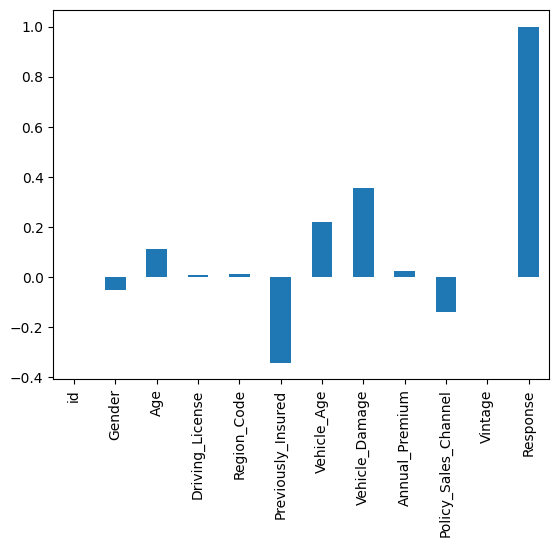

In [34]:
df.corr()['Response'].plot(kind='bar')

In [35]:
px.bar(df.corr()['Response'])

In [36]:
df=df.loc[:,['Vehicle_Damage','Previously_Insured','Vehicle_Age','Gender','Age','Annual_Premium','Response']]

In [37]:
df.sample(5)

,Vehicle_Damage,Previously_Insured,Vehicle_Age,Gender,Age,Annual_Premium,Response
67443,0,1,1,1,22,41956.0,0
233264,0,1,1,1,24,57770.0,0
122731,1,0,1,1,27,42319.0,0
327530,0,1,2,1,36,38325.0,0
176604,0,1,2,1,61,27781.0,0


<Axes: xlabel='Response', ylabel='count'>

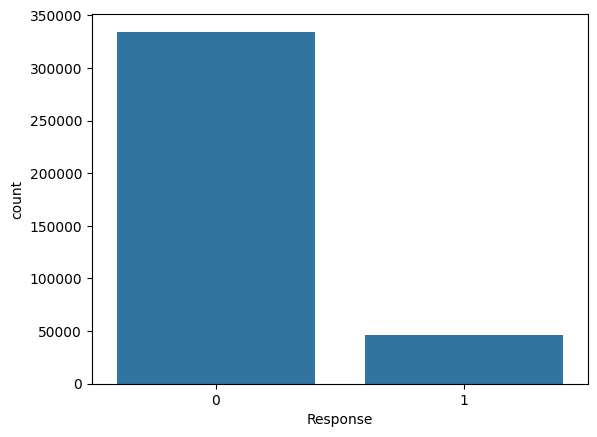

In [38]:
sns.countplot(x='Response', data=df)

In [39]:
df2=df

In [40]:
df

,Vehicle_Damage,Previously_Insured,Vehicle_Age,Gender,Age,Annual_Premium,Response
0,1,0,3,1,44,40454.0,1
1,0,0,2,1,76,33536.0,0
2,1,0,3,1,47,38294.0,1
3,0,1,1,1,21,28619.0,0
4,0,1,1,2,29,27496.0,0
...,...,...,...,...,...,...,...
381104,0,1,2,1,74,30170.0,0
381105,0,1,1,1,30,40016.0,0
381106,0,1,1,1,21,35118.0,0
381107,1,0,3,2,68,44617.0,0


In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X = df2.drop("Response", axis=1)   # features
y = df2["Response"]                # label

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test, 80% train
    random_state=42     # reproducible results
)


In [43]:
from sklearn.linear_model import LogisticRegressionCV
lr_cv_clf = LogisticRegressionCV(cv=5, random_state=0)

lr_cv_clf.fit(X_train,y_train)
y_pred = lr_cv_clf.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_test,y_pred))

Accuracy Score:  0.8750360788223872


In [44]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(max_depth=10, random_state=0)

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_test,y_pred))
scores = cross_val_score(clf, X_train, y_train, cv=10)
print("Accuracy Score with CV: ",scores.mean())

Accuracy Score:  0.875167274540159
Accuracy Score with CV:  0.878102378940406


In [ ]:
param_grid = {
    'bootstrap': [False,True],
    'max_depth': [5,8,10, 20],
    'max_features': [3, 4, 5, None],
    'min_samples_split': [2, 10, 12],
    'n_estimators': [100, 200, 300]
}

In [45]:
print("Precision Score: ", precision_score(y_test, y_pred,average='micro'))
print("Recall Score: ", recall_score(y_test, y_pred,average='micro'))
print("F1 Score: ", f1_score(y_test, y_pred,average='micro'))

Precision Score:  0.875167274540159
Recall Score:  0.875167274540159
F1 Score:  0.875167274540159


In [46]:
df.sample(5)

,Vehicle_Damage,Previously_Insured,Vehicle_Age,Gender,Age,Annual_Premium,Response
250699,1,0,2,1,36,36988.0,1
128415,1,0,1,2,22,34969.0,0
292494,0,1,2,1,71,43131.0,0
251225,0,1,2,1,46,46202.0,0
286821,1,0,2,1,57,25231.0,0


In [51]:
df_final=pd.read_csv('/kaggle/input/datasets/aa10sh/vehicle-insurrance-prediction/train.csv')

In [52]:
df_final.sample(4)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
38079,38080,Female,21,1,47.0,1,< 1 Year,No,28204.0,160.0,56,0
34377,34378,Male,23,1,9.0,0,< 1 Year,Yes,21235.0,152.0,161,0
162175,162176,Female,45,1,8.0,0,1-2 Year,Yes,57084.0,124.0,286,1
40796,40797,Female,25,1,30.0,1,< 1 Year,No,35608.0,152.0,195,0


In [50]:
df_final.sample(5)

,Vehicle_Damage,Previously_Insured,Vehicle_Age,Gender,Age,Annual_Premium,Response
98960,No,1,< 1 Year,Female,24,2630.0,0
91127,Yes,0,1-2 Year,Male,64,43840.0,0
215993,Yes,0,1-2 Year,Female,47,46736.0,1
22218,No,1,< 1 Year,Female,22,17176.0,0
327319,Yes,0,1-2 Year,Male,38,46429.0,0


In [53]:
df_final.to_csv("/kaggle/working/Final_data.csv", index=False)
